# 04 XGBoost Model

This notebook pushes the project one step beyond linear models.

XGBoost is a tree-ensemble method that can learn nonlinear effects and feature interactions. That makes it a natural follow-up to HAR-RV and Ridge when we want to test whether richer market-state information helps explain future realized volatility.

In [1]:
from pathlib import Path
import itertools
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

PROJECT_DIR = Path('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DF_PATH = DATA_DIR / 'model_df_2016_2025.csv.gz'

try:
    mpl_dir = PROJECT_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    mpl_dir = Path('/tmp/erdos_vol_pred_runtime/.matplotlib')
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

assert MODEL_DF_PATH.exists(), f'Run 01_data_download_and_features.ipynb first: {MODEL_DF_PATH}'
PROJECT_DIR

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')

## Why this feature set

XGBoost gets a **richer and more flexible** feature set than Ridge.

The model can benefit from nonlinearities and interactions, so here we keep:

- all stock-level engineered features,
- all dynamic market and macro proxy signals,
- ticker identity through one-hot encoding.

We explicitly **drop raw proxy level columns** such as absolute ETF prices or absolute rate levels, because we want the tree model to focus on returns, range, realized volatility, and normalized level signals instead of arbitrary price scales.

In [2]:
model_df = pd.read_csv(MODEL_DF_PATH, parse_dates=['Date'])

stock_feature_columns = [
    'abs_return', 'squared_return', 'high_low_log_range', 'log_volume',
    'hist_vol_5d', 'hist_vol_10d', 'hist_vol_21d', 'hist_vol_63d',
    'realized_vol_5d', 'realized_vol_10d', 'realized_vol_21d', 'realized_vol_63d',
    'volume_zscore_5d', 'volume_zscore_10d', 'volume_zscore_21d', 'volume_zscore_63d',
    'return_mean_5d', 'return_mean_21d',
    'abs_return_mean_5d', 'abs_return_mean_21d',
    'parkinson_vol_5d', 'parkinson_vol_21d',
]
dynamic_proxy_columns = [
    col for col in model_df.columns
    if (col.startswith('mkt_') or col.startswith('macro_')) and not col.endswith('_proxy_level')
]
xgb_numeric_features = stock_feature_columns + dynamic_proxy_columns
categorical_features = ['Ticker']
selected_tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']
validation_years = [2020, 2021, 2022, 2023, 2024]
test_year = 2025

xgb_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'min_child_weight': [5],
    'reg_lambda': [1, 5],
}

xgb_model_df = model_df[['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d'] + xgb_numeric_features].copy()
print('numeric feature count:', len(xgb_numeric_features))
xgb_model_df.head()

numeric feature count: 85


,Date,Ticker,fvol_5d,log_fvol_5d,abs_return,squared_return,high_low_log_range,log_volume,hist_vol_5d,hist_vol_10d,...,macro_HYG_proxy_level_zscore_21d,macro_LQD_proxy_level_zscore_21d,macro_^IRX_proxy_level_zscore_21d,macro_^TNX_proxy_level_zscore_21d,macro_^VIX_proxy_level_zscore_21d,macro_HYG_proxy_level_zscore_63d,macro_LQD_proxy_level_zscore_63d,macro_^IRX_proxy_level_zscore_63d,macro_^TNX_proxy_level_zscore_63d,macro_^VIX_proxy_level_zscore_63d
0,2016-04-05,AAPL,0.197562,-1.621702,0.011859,0.000141,0.011901,18.481915,0.190919,0.183323,...,-0.520611,1.643722,-1.083951,-2.174512,0.023680,1.026073,2.325323,-1.238452,-1.255325,-1.093170
1,2016-04-06,AAPL,0.209733,-1.561921,0.010419,0.000109,0.016169,18.475324,0.164979,0.185560,...,0.654182,1.464421,-0.965764,-1.559862,-0.679652,1.317958,2.151779,-1.206257,-1.040957,-1.358624
2,2016-04-07,AAPL,0.139626,-1.968790,0.022051,0.000486,0.021050,18.661331,0.240736,0.223664,...,-0.221432,1.568103,-0.877832,-2.075475,0.708161,1.099912,2.174090,-1.221767,-1.512423,-0.869497
3,2016-04-08,AAPL,0.200380,-1.607538,0.001105,0.000001,0.014683,18.362276,0.226111,0.220824,...,0.509746,1.275476,-0.841116,-1.527388,0.306475,1.237207,1.950836,-1.303594,-1.260494,-1.016639
4,2016-04-11,AAPL,0.252147,-1.377742,0.003308,0.000011,0.016223,18.583055,0.206184,0.216998,...,0.706467,1.184763,-0.924004,-1.331022,1.222256,1.248646,1.856731,-1.528512,-1.204848,-0.788569


## Shared evaluation protocol

This notebook keeps the same splits as HAR-RV and Ridge so the results stay directly comparable.

The only real difference is model flexibility: XGBoost can use nonlinear splits and feature interactions.

In [3]:
def volatility_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-8, None)
    errors = y_true - y_pred
    return {
        'rmse': float(np.sqrt(np.mean(errors ** 2))),
        'mae': float(np.mean(np.abs(errors))),
        'qlike': float(np.mean(np.log(y_pred ** 2) + (y_true ** 2) / (y_pred ** 2))),
    }

def make_param_grid(param_grid):
    keys = list(param_grid.keys())
    for values in itertools.product(*(param_grid[key] for key in keys)):
        yield dict(zip(keys, values))

def build_xgb_pipeline(params):
    preprocess = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', xgb_numeric_features),
            ('ticker', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features),
        ]
    )
    model = XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',
        random_state=42,
        n_jobs=4,
        verbosity=0,
        **params,
    )
    return Pipeline(
        steps=[
            ('preprocess', preprocess),
            ('model', model),
        ]
    )

def fit_predict_xgb(train_df, predict_df, params):
    pipeline = build_xgb_pipeline(params)
    X_train = train_df[categorical_features + xgb_numeric_features]
    y_train = train_df['log_fvol_5d']
    X_predict = predict_df[categorical_features + xgb_numeric_features]
    pipeline.fit(X_train, y_train)
    log_pred = pipeline.predict(X_predict)
    pred = np.exp(log_pred)
    return pipeline, pred

xgb_protocol = {
    'validation_years': validation_years,
    'test_year': test_year,
    'target': 'log_fvol_5d',
    'param_grid': xgb_param_grid,
}
xgb_protocol

{'validation_years': [2020, 2021, 2022, 2023, 2024],
 'test_year': 2025,
 'target': 'log_fvol_5d',
 'param_grid': {'n_estimators': [200, 400],
  'max_depth': [3, 5],
  'learning_rate': [0.03, 0.05],
  'subsample': [0.8],
  'colsample_bytree': [0.8],
  'min_child_weight': [5],
  'reg_lambda': [1, 5]}}

## Hyperparameter tuning with 5-fold expanding-window CV

We keep the parameter search intentionally small and structured. This is enough to test whether nonlinear modeling helps without turning the project into a heavy AutoML exercise.

The final parameter choice is the configuration with the best **average CV RMSE** across the five validation years.

In [4]:
xgb_cv_rows = []
xgb_param_list = list(make_param_grid(xgb_param_grid))

for validation_year in validation_years:
    train_fold = xgb_model_df[xgb_model_df['Date'].dt.year < validation_year].copy()
    validation_fold = xgb_model_df[xgb_model_df['Date'].dt.year == validation_year].copy()

    for params in xgb_param_list:
        _, validation_pred = fit_predict_xgb(train_fold, validation_fold, params)
        metrics = volatility_metrics(validation_fold['fvol_5d'], validation_pred)
        xgb_cv_rows.append(
            {
                'validation_year': validation_year,
                'param_key': json.dumps(params, sort_keys=True),
                'train_rows': len(train_fold),
                'validation_rows': len(validation_fold),
                **params,
                **metrics,
            }
        )

xgb_cv_results_df = pd.DataFrame(xgb_cv_rows)
xgb_cv_results_df.head()

,validation_year,param_key,train_rows,validation_rows,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_lambda,rmse,mae,qlike
0,2020,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",51810,13420,200,3,0.03,0.8,0.8,5,1,0.308163,0.169985,0.172126
1,2020,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",51810,13420,200,3,0.03,0.8,0.8,5,5,0.308546,0.170086,0.178868
2,2020,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",51810,13420,200,3,0.05,0.8,0.8,5,1,0.305138,0.168511,0.103447
3,2020,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",51810,13420,200,3,0.05,0.8,0.8,5,5,0.306255,0.169232,0.128522
4,2020,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",51810,13420,200,5,0.03,0.8,0.8,5,1,0.315566,0.174620,0.430908


In [5]:
xgb_param_summary_df = (
    xgb_cv_results_df.groupby('param_key', as_index=False)
    .agg(
        rmse=('rmse', 'mean'),
        mae=('mae', 'mean'),
        qlike=('qlike', 'mean'),
        n_estimators=('n_estimators', 'first'),
        max_depth=('max_depth', 'first'),
        learning_rate=('learning_rate', 'first'),
        subsample=('subsample', 'first'),
        colsample_bytree=('colsample_bytree', 'first'),
        min_child_weight=('min_child_weight', 'first'),
        reg_lambda=('reg_lambda', 'first'),
    )
    .sort_values('rmse')
    .reset_index(drop=True)
)
best_xgb_params = json.loads(xgb_param_summary_df.iloc[0]['param_key'])

xgb_fold_best_df = (
    xgb_cv_results_df.sort_values(['validation_year', 'rmse'])
    .groupby('validation_year', as_index=False)
    .first()
)

xgb_param_summary_df

,param_key,rmse,mae,qlike,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_lambda
0,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.167930,0.102191,-1.201588,200,3,0.05,0.8,0.8,5,5
1,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.167992,0.102267,-1.203620,200,3,0.05,0.8,0.8,5,1
2,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.168584,0.102348,-1.193211,200,3,0.03,0.8,0.8,5,1
3,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.168613,0.102395,-1.192277,200,3,0.03,0.8,0.8,5,5
4,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.169001,0.102909,-1.173125,400,3,0.03,0.8,0.8,5,1
5,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.169028,0.102225,-1.145310,200,5,0.03,0.8,0.8,5,5
6,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.169098,0.102996,-1.160684,400,3,0.05,0.8,0.8,5,5
7,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.169220,0.102969,-1.167861,400,3,0.03,0.8,0.8,5,5
8,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.169360,0.102434,-1.137372,200,5,0.03,0.8,0.8,5,1
9,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.169371,0.103172,-1.155276,400,3,0.05,0.8,0.8,5,1


In [6]:
xgb_fold_best_df[['validation_year', 'n_estimators', 'max_depth', 'learning_rate', 'reg_lambda', 'rmse', 'mae', 'qlike']]

,validation_year,n_estimators,max_depth,learning_rate,reg_lambda,rmse,mae,qlike
0,2020,200,3,0.05,1,0.305138,0.168511,0.103447
1,2021,400,3,0.05,5,0.110625,0.076697,-1.789699
2,2022,200,5,0.03,5,0.155018,0.100829,-1.079582
3,2023,400,5,0.05,5,0.119805,0.075982,-1.743335
4,2024,400,3,0.05,5,0.142610,0.083407,-1.576781


## Final training and 2025 holdout test

Once the best parameter set is chosen from CV, we retrain on all data through 2024 and then test only on 2025.

In [7]:
xgb_final_train_df = xgb_model_df[xgb_model_df['Date'].dt.year < test_year].copy()
xgb_test_df = xgb_model_df[xgb_model_df['Date'].dt.year == test_year].copy()

xgb_final_model, xgb_test_pred = fit_predict_xgb(xgb_final_train_df, xgb_test_df, best_xgb_params)

xgboost_predictions_df = xgb_test_df[['Date', 'Ticker', 'fvol_5d']].reset_index(drop=True).copy()
xgboost_predictions_df['prediction'] = np.asarray(xgb_test_pred, dtype=float)

xgb_test_metrics_df = pd.DataFrame([volatility_metrics(xgboost_predictions_df['fvol_5d'], xgboost_predictions_df['prediction'])])
xgb_test_metrics_df

,rmse,mae,qlike
0,0.159819,0.095069,-1.343346


In [8]:
xgboost_predictions_df.head()

,Date,Ticker,fvol_5d,prediction
0,2025-01-02,AAPL,0.198237,0.185743
1,2025-01-03,AAPL,0.211053,0.163641
2,2025-01-06,AAPL,0.208389,0.170669
3,2025-01-07,AAPL,0.236536,0.176225
4,2025-01-08,AAPL,0.376107,0.166237


## Plot predictions for five representative stocks

We use the same five names as the earlier notebooks so the visual comparison stays one-to-one.

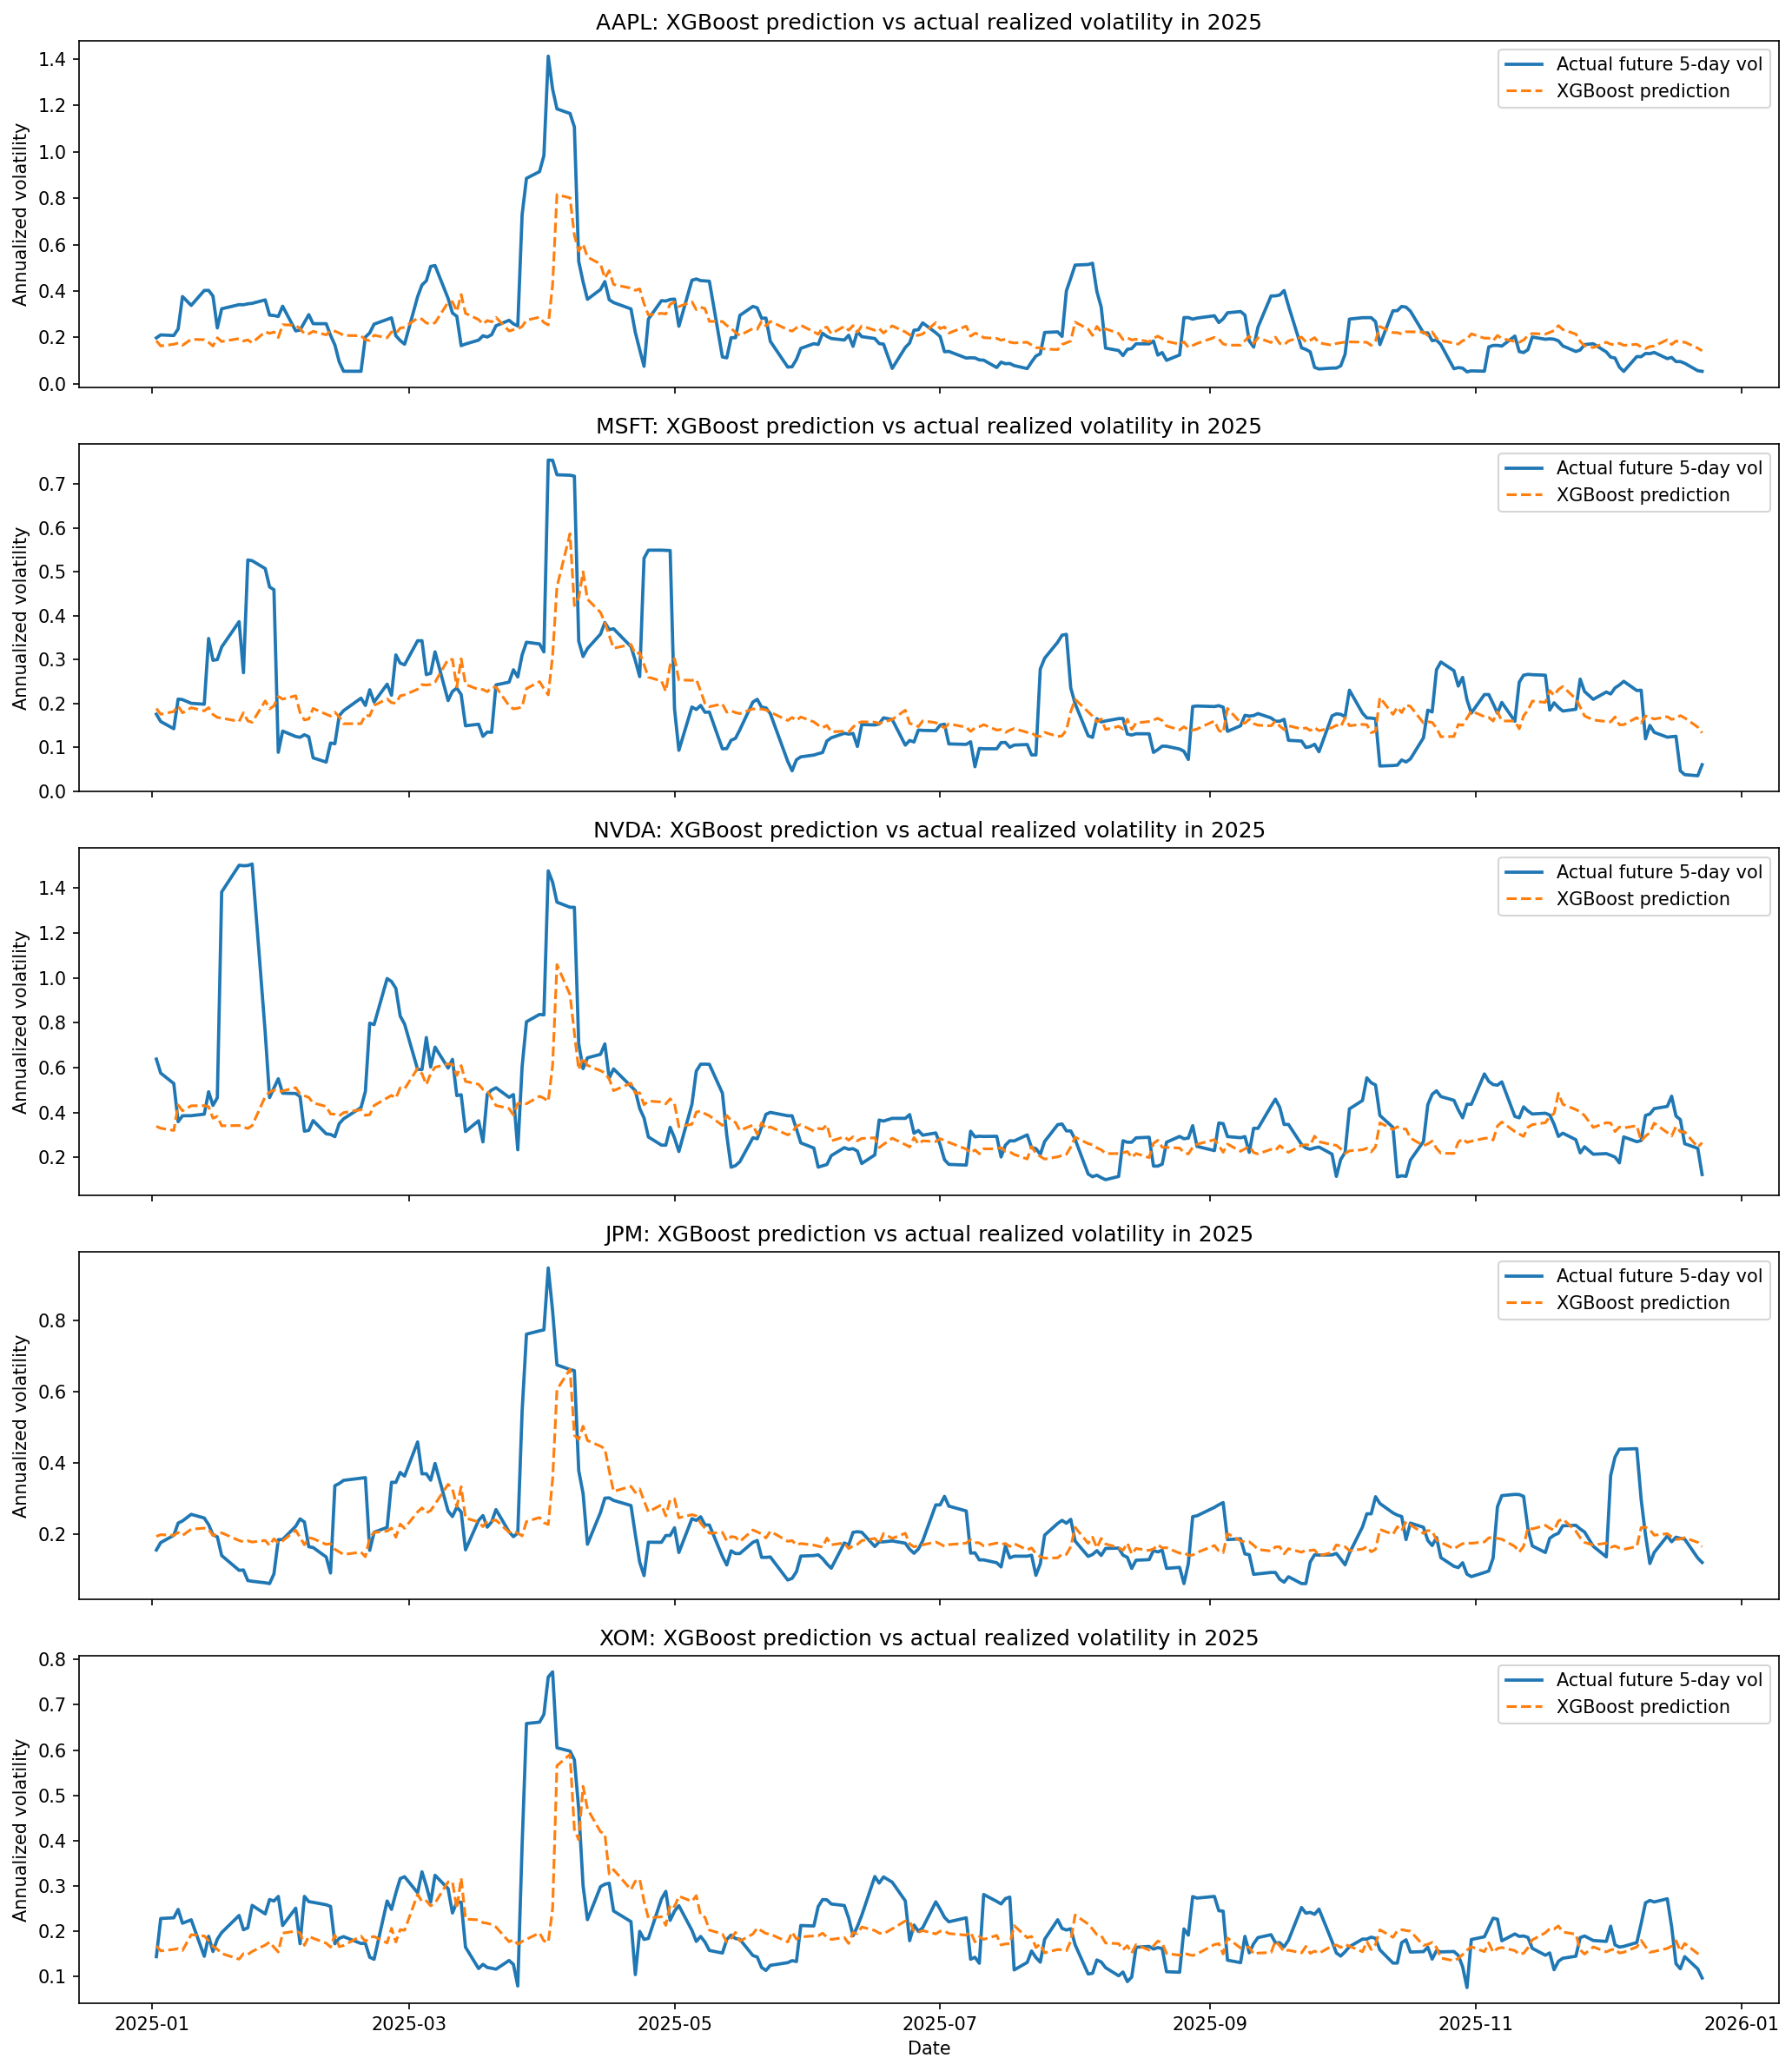

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project/figures/xgboost_test_predictions_5stocks.png')

In [9]:
fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 16), sharex=True)

for ax, ticker in zip(axes, selected_tickers):
    stock_plot_df = xgboost_predictions_df[xgboost_predictions_df['Ticker'] == ticker].sort_values('Date')
    ax.plot(stock_plot_df['Date'], stock_plot_df['fvol_5d'], label='Actual future 5-day vol', linewidth=1.8)
    ax.plot(stock_plot_df['Date'], stock_plot_df['prediction'], label='XGBoost prediction', linestyle='--', linewidth=1.5)
    ax.set_title(f'{ticker}: XGBoost prediction vs actual realized volatility in 2025')
    ax.set_ylabel('Annualized volatility')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()

xgb_plot_path = FIGURE_DIR / 'xgboost_test_predictions_5stocks.png'
plt.savefig(xgb_plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(xgb_plot_path)))

xgb_plot_path

## How to compare this with HAR-RV and Ridge

If XGBoost beats both earlier models, that suggests the volatility problem is not purely linear and that interactions across stock, market, and macro features matter.

If it does **not** beat Ridge by much, that is still informative: it means most of the signal may already be captured by a relatively simple regularized regression.